# Implementacao Completa: Classificacao Multiclasse (3 Classes)

Este notebook segue o template multiclass e aplica um fluxo completo para o dataset final do projeto.

Objetivos deste notebook:
- Carregar o arquivo final `data/data_set_final.csv` gerado pelo script de codificacao.
- Realizar analise exploratoria (EDA) com graficos para entender distribuicoes e relacoes.
- Preparar os dados sem alterar os valores finais do dataset.
- Treinar um modelo multiclass com 3 classes e avaliar acuracia e metricas por classe.

Mapeamento da classe alvo (`CLASSI_FIN`):
- 0 = OUTRAS_DOENCAS
- 1 = CHIKUNGUNYA
- 2 = DENGUE

In [13]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.callbacks import EarlyStopping

# Configuracoes visuais e de logs para facilitar analise.
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
gpu = tf.config.experimental.list_physical_devices('GPU')

print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Visible GPUs:", gpu)

TensorFlow version: 2.21.0
Built with CUDA: True
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## STEP 1: Load Data (Dataset Final)

In [14]:
# Caminho oficial do dataset final gerado pelo script de codificacao.
DATA_PATH = "../data/data_set_final.csv"
TARGET_COL = "CLASSI_FIN"
CLASS_NAME_MAP = {0: "OUTRAS_DOENCAS", 1: "CHIKUNGUNYA", 2: "DENGUE"}

df = pd.read_csv(DATA_PATH)

# Garantimos que a coluna alvo seja numerica para treino multiclass.
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="raise").astype(int)

print("Dataset carregado com sucesso:", DATA_PATH)
print("Shape:", df.shape)
print("Colunas:", len(df.columns))
df.head()

Dataset carregado com sucesso: ../data/data_set_final.csv
Shape: (17172, 27)
Colunas: 27


,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ZONA,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,...,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DIAS,CLASSI_FIN
0,4022.0,0,5.0,1.0,3.0,1.0,1.0,1.0,2.0,2.0,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1,1
1,4020.0,1,6.0,4.0,1.0,1.0,1.0,1.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,6,1
2,4061.0,0,6.0,4.0,1.0,1.0,1.0,1.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,32,1
3,4046.0,1,6.0,4.0,1.0,1.0,1.0,1.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,1
4,4014.0,1,6.0,4.0,1.0,1.0,1.0,1.0,2.0,1.0,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,1


## STEP 2: Data Inspection and Quality Checks

In [15]:
# Inspecao estrutural para validar se os dados finais estao prontos para modelagem.
print("Tipos de dados:")
print(df.dtypes)

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

print("\nDistribuicao da classe alvo (codigo):")
print(df[TARGET_COL].value_counts().sort_index())

# Estatisticas descritivas das variaveis numericas.
df.describe().T.head(10)

Tipos de dados:
NU_IDADE_N    float64
CS_SEXO         int64
CS_GESTANT    float64
CS_RACA       float64
CS_ZONA       float64
FEBRE         float64
MIALGIA       float64
CEFALEIA      float64
EXANTEMA      float64
VOMITO        float64
NAUSEA        float64
DOR_COSTAS    float64
CONJUNTVIT    float64
ARTRITE       float64
ARTRALGIA     float64
PETEQUIA_N    float64
LACO          float64
DOR_RETRO     float64
DIABETES      float64
HEMATOLOG     float64
HEPATOPAT     float64
RENAL         float64
HIPERTENSA    float64
ACIDO_PEPT    float64
AUTO_IMUNE    float64
DIAS            int64
CLASSI_FIN      int64
dtype: object

Valores ausentes por coluna:
NU_IDADE_N    0
CS_SEXO       0
CS_GESTANT    0
CS_RACA       0
CS_ZONA       0
FEBRE         0
MIALGIA       0
CEFALEIA      0
EXANTEMA      0
VOMITO        0
NAUSEA        0
DOR_COSTAS    0
CONJUNTVIT    0
ARTRITE       0
ARTRALGIA     0
PETEQUIA_N    0
LACO          0
DOR_RETRO     0
DIABETES      0
HEMATOLOG     0
HEPATOPAT     0
RENAL     

,count,mean,std,min,25%,50%,75%,max
NU_IDADE_N,17172.0,3995.652923,241.180628,11.0,4016.0,4031.0,4047.0,4400.0
CS_SEXO,17172.0,0.426217,0.497593,0.0,0.0,0.0,1.0,2.0
CS_GESTANT,17172.0,6.359830,1.481539,0.0,6.0,6.0,6.0,9.0
CS_RACA,17172.0,6.975076,2.696598,0.0,4.0,9.0,9.0,9.0
CS_ZONA,17172.0,2.098125,2.739476,1.0,1.0,1.0,1.0,9.0
FEBRE,17172.0,1.147042,0.354158,1.0,1.0,1.0,1.0,2.0
MIALGIA,17172.0,1.415968,0.492902,1.0,1.0,1.0,2.0,2.0
CEFALEIA,17172.0,1.394014,0.488652,1.0,1.0,1.0,2.0,2.0
EXANTEMA,17172.0,1.744060,0.436401,1.0,1.0,2.0,2.0,2.0
VOMITO,17172.0,1.807128,0.394565,1.0,2.0,2.0,2.0,2.0


## STEP 3: Visualize Target Distribution

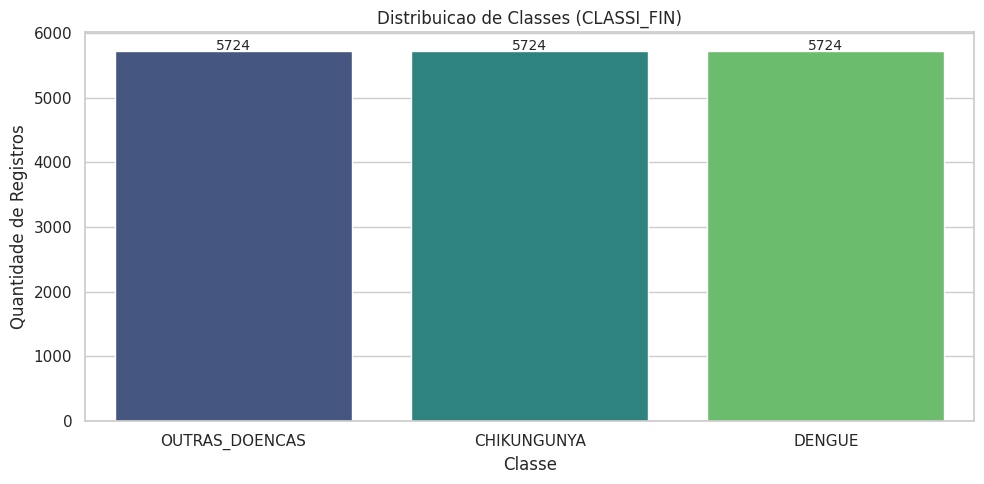

In [16]:
# Grafico da distribuicao das classes para confirmar o balanceamento do dataset.
class_counts = df[TARGET_COL].value_counts().sort_index()
labels = [CLASS_NAME_MAP.get(i, str(i)) for i in class_counts.index]

ax = sns.barplot(x=labels, y=class_counts.values, palette="viridis")
ax.set_title("Distribuicao de Classes (CLASSI_FIN)")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade de Registros")

for idx, value in enumerate(class_counts.values):
    ax.text(idx, value + 20, str(value), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## STEP 4: Correlation Analysis

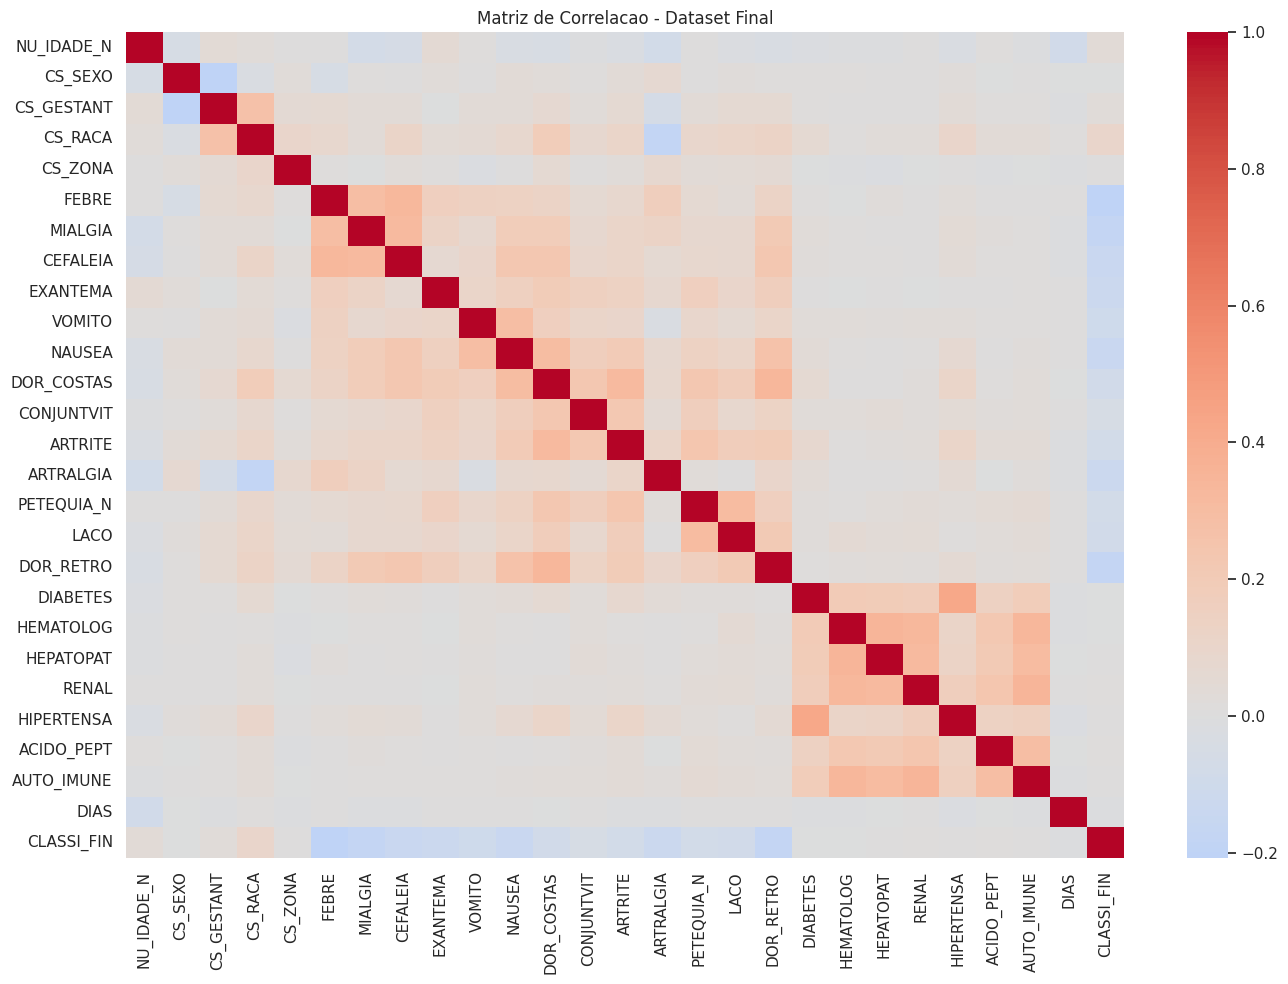

In [17]:
# Mapa de calor para observar relacoes lineares entre atributos numericos.
plt.figure(figsize=(14, 10))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, cmap="coolwarm", center=0)
plt.title("Matriz de Correlacao - Dataset Final")
plt.tight_layout()
plt.show()

## STEP 5: Prepare Features and Target

In [18]:
# Separamos atributos (X) e alvo (y) sem alterar valores do dataset final.
X = df.drop(columns=[TARGET_COL]).values
y = df[TARGET_COL].astype(int).values

classes = np.unique(y)
print("Detected classes:", classes)
if len(classes) != 3:
    raise ValueError(f"Expected exactly 3 classes, but found {len(classes)}: {classes}")
if set(classes.tolist()) != {0, 1, 2}:
    raise ValueError("As classes esperadas para CLASSI_FIN sao exatamente 0, 1 e 2.")

print("X shape:", X.shape)
print("y shape:", y.shape)

Detected classes: [0 1 2]
X shape: (17172, 26)
y shape: (17172,)


## STEP 6: Train/Test Split and Feature Scaling

In [19]:
# Split estratificado para manter proporcoes de classe no treino e teste.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Verificacao explicita das proporcoes por classe para garantir imparcialidade.
full_ratio = pd.Series(y).value_counts(normalize=True).sort_index()
train_ratio = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_ratio = pd.Series(y_test).value_counts(normalize=True).sort_index()

counts_df = pd.DataFrame(
    {
        "full_count": pd.Series(y).value_counts().sort_index(),
        "train_count": pd.Series(y_train).value_counts().sort_index(),
        "test_count": pd.Series(y_test).value_counts().sort_index(),
        "full_ratio": full_ratio,
        "train_ratio": train_ratio,
        "test_ratio": test_ratio,
    }
)

print("Distribuicao por classe apos split:")
display(counts_df)

# Tolerancia pequena para arredondamentos de contagem.
if not np.allclose(train_ratio.values, full_ratio.values, atol=1e-3):
    raise ValueError("Proporcao das classes no treino difere da base completa.")
if not np.allclose(test_ratio.values, full_ratio.values, atol=1e-3):
    raise ValueError("Proporcao das classes no teste difere da base completa.")

# O scaler e ajustado apenas no treino para evitar leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train_scaled.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test_scaled.shape)
print("y_test shape:", y_test.shape)

Distribuicao por classe apos split:


,full_count,train_count,test_count,full_ratio,train_ratio,test_ratio
0,5724,4579,1145,0.333333,0.333333,0.333333
1,5724,4579,1145,0.333333,0.333333,0.333333
2,5724,4579,1145,0.333333,0.333333,0.333333


X_train shape: (13737, 26)
y_train shape: (13737,)
X_test shape: (3435, 26)
y_test shape: (3435,)


## STEP 7: Build and Compile Multiclass Model

In [20]:
# Arquitetura base inspirada no template multiclass.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(3, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,907 (46.51 KB)

 Trainable params: 11,907 (46.51 KB)

 Non-trainable params: 0 (0.00 B)

## STEP 8: Train Model

In [21]:
# Early stopping reduz risco de overfitting em treinos longos.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=120,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/120


I0000 00:00:1775942504.770776  136983 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_70933__.15


342/344 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5014 - loss: 1.0102

I0000 00:00:1775942506.264326  136985 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_70933__.15


344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5525 - loss: 0.9484 - val_accuracy: 0.6012 - val_loss: 0.8788
Epoch 2/120
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5923 - loss: 0.8899 - val_accuracy: 0.6084 - val_loss: 0.8646
Epoch 3/120
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5998 - loss: 0.8711 - val_accuracy: 0.6146 - val_loss: 0.8650
Epoch 4/120
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6036 - loss: 0.8621 - val_accuracy: 0.6139 - val_loss: 0.8609
Epoch 5/120
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6068 - loss: 0.8597 - val_accuracy: 0.6070 - val_loss: 0.8608
Epoch 6/120
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6087 - loss: 0.8517 - val_accuracy: 0.6135 - val_loss: 0.8548
Epoch 7/120
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6160 - loss: 0.8432 - val_accuracy: 0.6179 - val_loss: 0.8564
Epoch 8/120
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6112 - loss: 0.8438 - val_accuracy: 0.6172

## STEP 9: Evaluate Accuracy and Classification Metrics

Test loss: 0.8498
Test accuracy: 0.6096

Accuracy (sklearn): 0.6096


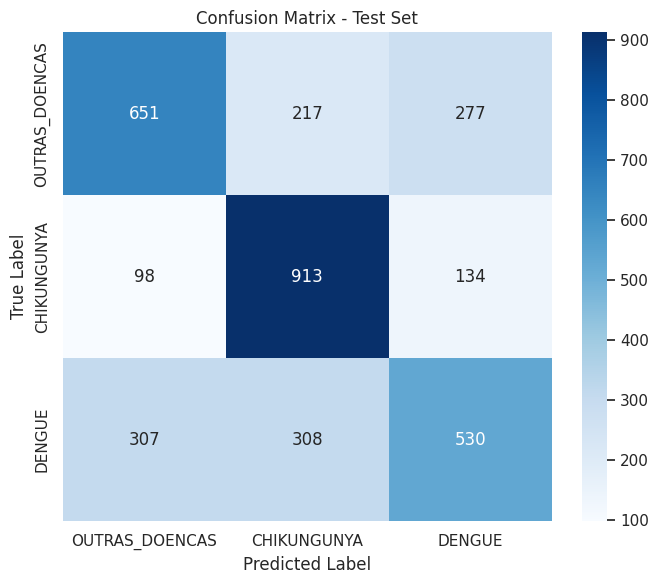


Classification Report:
                precision    recall  f1-score   support

OUTRAS_DOENCAS     0.6165    0.5686    0.5915      1145
   CHIKUNGUNYA     0.6349    0.7974    0.7069      1145
        DENGUE     0.5632    0.4629    0.5081      1145

      accuracy                         0.6096      3435
     macro avg     0.6049    0.6096    0.6022      3435
  weighted avg     0.6049    0.6096    0.6022      3435



In [22]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# Predicao final por argmax nas probabilidades da softmax.
probs = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(probs, axis=1)

print("\nAccuracy (sklearn):", f"{accuracy_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[CLASS_NAME_MAP[i] for i in sorted(CLASS_NAME_MAP)],
    yticklabels=[CLASS_NAME_MAP[i] for i in sorted(CLASS_NAME_MAP)],
)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[CLASS_NAME_MAP[i] for i in sorted(CLASS_NAME_MAP)],
        digits=4,
    )
)

## STEP 10: Training Curves (Loss and Accuracy)

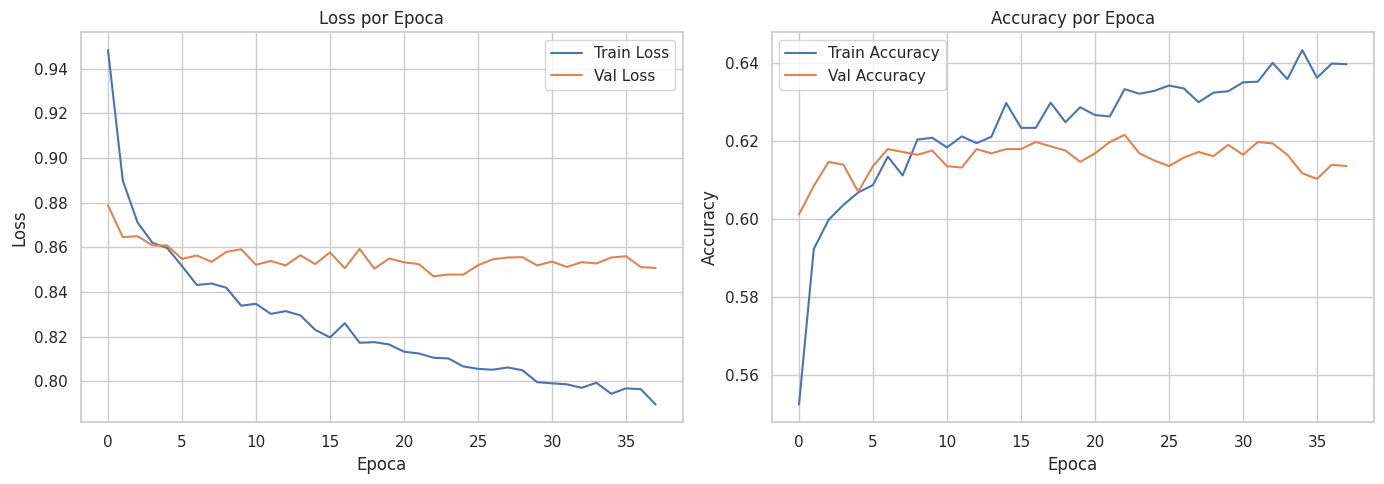

In [23]:
# Curvas de treino e validacao para analisar convergencia e overfitting.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss por Epoca")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy por Epoca")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()